# Day 2: Linear Regression Implementation & Analysis (2.3)

## Table of Contents
1. [Lab Overview](#lab-overview)
   - Objective
   - Dataset Description
   - Key Concepts to Apply
2. [Multiple Linear Regression Implementation](#mlr-implementation)
   - Data Preparation
   - Model Training
   - Model Evaluation (Training vs. Test)
   - Interpretation of Coefficients
   - Analyzing for Overfitting/Underfitting
3. [Simple Linear Regression Implementation](#slr-implementation)
   - Feature Selection
   - Model Training
   - Model Evaluation
   - Comparing SLR vs. MLR Performance
4. [Feature Importance Analysis](#feature-importance)
   - Understanding Coefficient Magnitudes
   - Visualizing Feature Importance
   - Considerations for Interpretation
5. [Assumption Checking](#assumption-checking)
   - Residual Analysis for Linearity
   - Checking Homoscedasticity
   - Normality of Residuals
   - Additional Diagnostics
6. [Interactive Exercises](#interactive-exercises)
   - Modifying the Analysis
   - Exploring Different Features
   - Visualization Challenges
7. [Practice Questions](#practice-questions)

<a id="lab-overview"></a>

## Lab Overview

### Objective

In this lab session, we will implement and analyze both Simple and Multiple Linear Regression models using the California Housing dataset. Our goals are to:

1. Apply the Scikit-learn Linear Regression implementation
2. Calculate and interpret various evaluation metrics
3. Compare model performance on training and test sets to detect potential overfitting/underfitting
4. Compare models with different numbers of features
5. Check linear regression assumptions
6. Extract actionable insights from the models

### Dataset Description

We'll continue using the **California Housing dataset** from Day 1. This dataset contains information about housing in California districts, collected from the 1990 California census. Each row in the dataset represents a California district, and we'll predict the median house value based on various district-level features.

**Features in the California Housing dataset:**
- MedInc: Median income in block group (in tens of thousands of US Dollars)
- HouseAge: Median house age in block group (in years)
- AveRooms: Average number of rooms per household
- AveBedrms: Average number of bedrooms per household
- Population: Block group population
- AveOccup: Average number of household members
- Latitude: Block group latitude
- Longitude: Block group longitude

**Target Variable:**
- MedHouseVal: Median house value (in hundreds of thousands of US Dollars)

### Key Concepts to Apply

Throughout this lab, we'll apply several key concepts discussed in today's lecture:

- Training both Multiple and Simple Linear Regression models
- Evaluating models using MSE, RMSE, MAE, and R²
- Comparing training and test performance to detect overfitting/underfitting
- Checking linear regression assumptions through residual analysis
- Interpreting model coefficients and feature importance

<a id="mlr-implementation"></a>

## Multiple Linear Regression Implementation

Let's start by implementing a Multiple Linear Regression model that uses all available features in the dataset.

### Data Preparation

First, we'll load and prepare the data, following the same approach as Day 1:

In [45]:
# --- Import Libraries ---
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nicer aesthetic style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [47]:
# --- Load and Prepare Data ---
# Load the California Housing dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

# Examine the data structure
print("\nDataset Shape:", df.shape)


Dataset Shape: (20640, 9)


In [48]:
print("\nFeature Names:", california.feature_names)


Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [49]:
print("\nFirst 5 rows of the DataFrame:")
df.head()


First 5 rows of the DataFrame:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [50]:
# Split features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

In [51]:
# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nData loaded and split.")
print("Training set shapes (X, y):", X_train.shape, y_train.shape)
print("Testing set shapes (X, y):", X_test.shape, y_test.shape)


Data loaded and split.
Training set shapes (X, y): (16512, 8) (16512,)
Testing set shapes (X, y): (4128, 8) (4128,)


### Model Training

Next, we'll instantiate and train a Multiple Linear Regression model using all features:

In [53]:
# --- Multiple Linear Regression (Using all features) ---
print("\n--- Multiple Linear Regression (All Features) ---")

# 1. Instantiate the model
mlr_model = LinearRegression()

# 2. Train the model on the training data
mlr_model.fit(X_train, y_train)
print("MLR Model Trained.")

# 3. Make predictions on BOTH Training and Test sets
# This allows us to compare performance and check for overfitting
y_pred_train_mlr = mlr_model.predict(X_train)
y_pred_test_mlr = mlr_model.predict(X_test)
print("Predictions made for Train and Test sets.")


--- Multiple Linear Regression (All Features) ---
MLR Model Trained.
Predictions made for Train and Test sets.


### Model Evaluation (Training vs. Test)

Now, we'll evaluate the model's performance on both the training and test sets to assess how well it generalizes:

In [54]:
# --- Evaluate MLR Performance ---
print("\nMLR Evaluation:")

# Training Set Performance
mse_train_mlr = mean_squared_error(y_train, y_pred_train_mlr)
rmse_train_mlr = np.sqrt(mse_train_mlr)
mae_train_mlr = mean_absolute_error(y_train, y_pred_train_mlr)
r2_train_mlr = r2_score(y_train, y_pred_train_mlr)

print("  Training Set Metrics:")
print(f"  MSE:   {mse_train_mlr:.4f}")
print(f"  RMSE:  {rmse_train_mlr:.4f}")
print(f"  MAE:   {mae_train_mlr:.4f}")
print(f"  R²:    {r2_train_mlr:.4f}")


MLR Evaluation:
  Training Set Metrics:
  MSE:   0.5179
  RMSE:  0.7197
  MAE:   0.5286
  R²:    0.6126


In [55]:
# Test Set Performance
mse_test_mlr = mean_squared_error(y_test, y_pred_test_mlr)
rmse_test_mlr = np.sqrt(mse_test_mlr)
mae_test_mlr = mean_absolute_error(y_test, y_pred_test_mlr)
r2_test_mlr = r2_score(y_test, y_pred_test_mlr)

print("\n  Test Set Metrics:")
print(f"  MSE:   {mse_test_mlr:.4f}")
print(f"  RMSE:  {rmse_test_mlr:.4f}")
print(f"  MAE:   {mae_test_mlr:.4f}")
print(f"  R²:    {r2_test_mlr:.4f}")


  Test Set Metrics:
  MSE:   0.5559
  RMSE:  0.7456
  MAE:   0.5332
  R²:    0.5758


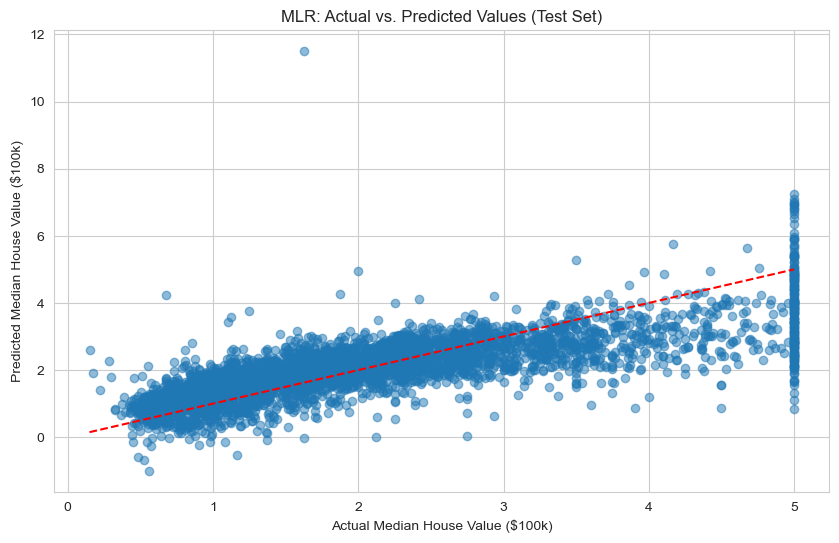

In [11]:
# Visualize actual vs. predicted values on test set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test_mlr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Median House Value ($100k)')
plt.ylabel('Predicted Median House Value ($100k)')
plt.title('MLR: Actual vs. Predicted Values (Test Set)')
plt.grid(True)
plt.show()

### Interpretation of Coefficients

The coefficients in a linear regression model tell us about the relationships between each feature and the target variable:

In [12]:
# --- Interpret Model Coefficients ---
print("\nMLR Model Coefficients:")
# Create a DataFrame to display feature names alongside coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_
})
print(coefficients)

# Add the intercept
print(f"\nIntercept: {mlr_model.intercept_:.4f}")

# Example interpretation
print("\nInterpretation example:")
print(f"For each additional unit of MedInc (median income in tens of thousands), ")
print(f"house values increase by ${coefficients.loc[coefficients['Feature'] == 'MedInc', 'Coefficient'].values[0]:.4f} hundred thousand")
print(f"or ${coefficients.loc[coefficients['Feature'] == 'MedInc', 'Coefficient'].values[0] * 100:.0f} thousand dollars,")
print("holding all other features constant.")


MLR Model Coefficients:
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708

Intercept: -37.0233

Interpretation example:
For each additional unit of MedInc (median income in tens of thousands), 
house values increase by $0.4487 hundred thousand
or $45 thousand dollars,
holding all other features constant.


### Analyzing for Overfitting/Underfitting

We'll compare training and test metrics to check for potential overfitting or underfitting:

In [56]:
# --- Check for Overfitting/Underfitting ---
print("\nAnalysis for Overfitting/Underfitting:")
print(f"  Training R²: {r2_train_mlr:.4f}")
print(f"  Test R²:     {r2_test_mlr:.4f}")
print(f"  R² Difference (Train - Test): {r2_train_mlr - r2_test_mlr:.4f}")


Analysis for Overfitting/Underfitting:
  Training R²: 0.6126
  Test R²:     0.5758
  R² Difference (Train - Test): 0.0368


In [57]:
# Compare RMSE train vs test
print(f"  Training RMSE: {rmse_train_mlr:.4f}")
print(f"  Test RMSE:     {rmse_test_mlr:.4f}")
print(f"  RMSE Ratio (Test/Train): {rmse_test_mlr/rmse_train_mlr:.4f}")

  Training RMSE: 0.7197
  Test RMSE:     0.7456
  RMSE Ratio (Test/Train): 1.0360


In [59]:
# Interpretation
if abs(r2_train_mlr - r2_test_mlr) < 0.05:
    print("\nInterpretation: The model shows similar performance on both training and test sets,")
    print("suggesting good generalization without significant overfitting.")
elif r2_train_mlr - r2_test_mlr > 0.1:
    print("\nInterpretation: The model performs notably better on the training set than the test set,")
    print("which may indicate some overfitting.")
else:
    print("\nInterpretation: The model shows reasonable generalization with some difference")
    print("between training and test performance.")

if r2_train_mlr < 0.5 and r2_test_mlr < 0.5:
    print("\nBoth training and test R² values are relatively low, which might suggest underfitting.")
    print("The linear model may be too simple to capture the underlying patterns in the data.")


Interpretation: The model shows similar performance on both training and test sets,
suggesting good generalization without significant overfitting.


<a id="slr-implementation"></a>
## Simple Linear Regression Implementation

Now, we'll implement a Simple Linear Regression model using only the median income feature (MedInc), which is typically strongly correlated with house prices.

### Feature Selection

In [15]:
# --- Simple Linear Regression (Using only MedInc) ---
print("\n--- Simple Linear Regression (Feature: MedInc) ---")

# 1. Select the single feature
# We use double brackets to keep it as a DataFrame (not a Series)
X_train_slr = X_train[['MedInc']]
X_test_slr = X_test[['MedInc']]


--- Simple Linear Regression (Feature: MedInc) ---


### Model Training

In [16]:
# 2. Instantiate and train Simple Linear Regression model
slr_model = LinearRegression()
slr_model.fit(X_train_slr, y_train)
print("SLR Model Trained.")

# 3. Make predictions
y_pred_train_slr = slr_model.predict(X_train_slr)
y_pred_test_slr = slr_model.predict(X_test_slr)
print("Predictions made for Train and Test sets.")

# Extract coefficient and intercept for interpretation
slope = slr_model.coef_[0]
intercept = slr_model.intercept_

print(f"\nSLR Model Equation: MedHouseVal = {intercept:.4f} + {slope:.4f} × MedInc")
print(f"This means for every $10,000 increase in median income,")
print(f"house values increase by ${slope:.4f} hundred thousand dollars (${slope*100:.0f}K).")

SLR Model Trained.
Predictions made for Train and Test sets.

SLR Model Equation: MedHouseVal = 0.4446 + 0.4193 × MedInc
This means for every $10,000 increase in median income,
house values increase by $0.4193 hundred thousand dollars ($42K).


### Model Evaluation

In [18]:
# 4. Evaluate SLR Performance
print("\nSLR Evaluation:")

# Training Set Performance
r2_train_slr = r2_score(y_train, y_pred_train_slr)
rmse_train_slr = np.sqrt(mean_squared_error(y_train, y_pred_train_slr))
mae_train_slr = mean_absolute_error(y_train, y_pred_train_slr)

print("  Training Set Metrics:")
print(f"  RMSE: {rmse_train_slr:.4f}")
print(f"  MAE:  {mae_train_slr:.4f}")
print(f"  R²:   {r2_train_slr:.4f}")

# Test Set Performance
r2_test_slr = r2_score(y_test, y_pred_test_slr)
rmse_test_slr = np.sqrt(mean_squared_error(y_test, y_pred_test_slr))
mae_test_slr = mean_absolute_error(y_test, y_pred_test_slr)

print("\n  Test Set Metrics:")
print(f"  RMSE: {rmse_test_slr:.4f}")
print(f"  MAE:  {mae_test_slr:.4f}")
print(f"  R²:   {r2_test_slr:.4f}")


SLR Evaluation:
  Training Set Metrics:
  RMSE: 0.8361
  MAE:  0.6250
  R²:   0.4770

  Test Set Metrics:
  RMSE: 0.8421
  MAE:  0.6299
  R²:   0.4589


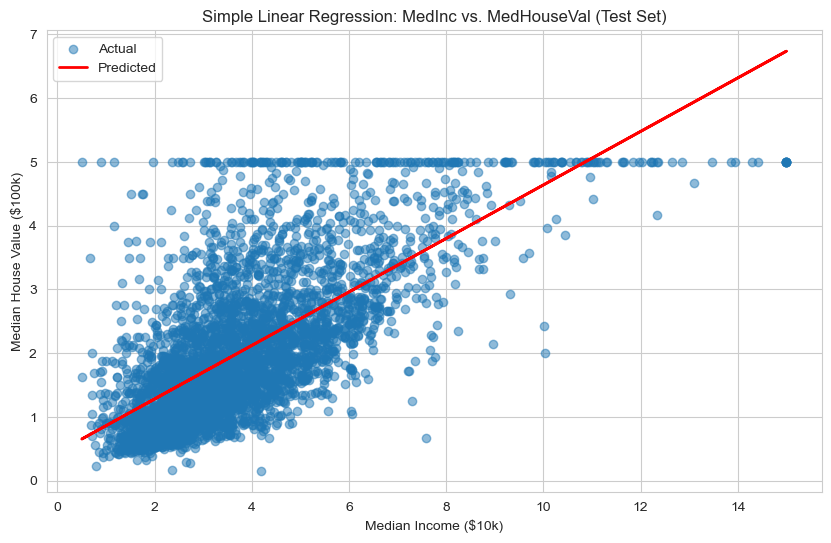

In [20]:
# Visualize the SLR model
plt.figure(figsize=(10, 6))
plt.scatter(X_test_slr, y_test, alpha=0.5, label='Actual')
plt.plot(X_test_slr, y_pred_test_slr, color='red', linewidth=2, label='Predicted')
plt.xlabel('Median Income ($10k)')
plt.ylabel('Median House Value ($100k)')
plt.title('Simple Linear Regression: MedInc vs. MedHouseVal (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

### Comparing SLR vs. MLR Performance

In [22]:
# 5. Compare SLR vs MLR performance
print("\nModel Comparison (Test Set):")
print(f"  MLR (All features) R²:  {r2_test_mlr:.4f}")
print(f"  SLR (MedInc only) R²:   {r2_test_slr:.4f}")
print(f"  R² Difference:          {r2_test_mlr - r2_test_slr:.4f}")

print(f"  MLR RMSE: {rmse_test_mlr:.4f}")
print(f"  SLR RMSE: {rmse_test_slr:.4f}")
print(f"  RMSE Improvement:       {rmse_test_slr - rmse_test_mlr:.4f}")
print(f"  Percentage Improvement:  {(rmse_test_slr - rmse_test_mlr) / rmse_test_slr * 100:.2f}%")

# Interpretation
print("\nInterpretation:")
if r2_test_mlr - r2_test_slr > 0.1:
    print("The Multiple Linear Regression model (using all features) explains significantly more variance")
    print(f"({r2_test_mlr:.4f} vs {r2_test_slr:.4f}) than the Simple Linear Regression model using only median income.")
    print("This indicates that the additional features provide valuable information for predicting house prices.")
else:
    print("The Multiple Linear Regression model provides only modest improvements over the Simple model.")
    print("This suggests that median income alone captures much of the predictive information.")


Model Comparison (Test Set):
  MLR (All features) R²:  0.5758
  SLR (MedInc only) R²:   0.4589
  R² Difference:          0.1169
  MLR RMSE: 0.7456
  SLR RMSE: 0.8421
  RMSE Improvement:       0.0965
  Percentage Improvement:  11.46%

Interpretation:
The Multiple Linear Regression model (using all features) explains significantly more variance
(0.5758 vs 0.4589) than the Simple Linear Regression model using only median income.
This indicates that the additional features provide valuable information for predicting house prices.


<a id="feature-importance"></a>
## Feature Importance Analysis

Understanding which features most strongly influence predictions is crucial for interpretation and feature selection:

In [23]:
# --- Feature Importance Analysis ---
print("\n--- Feature Importance Analysis ---")

# Display coefficients alongside feature names
coeffs = pd.Series(mlr_model.coef_, index=X.columns)

# Sort by absolute value to find most influential features
coeffs_sorted = coeffs.abs().sort_values(ascending=False)
print("Features sorted by importance (based on coefficient magnitude):")
print(coeffs_sorted)


--- Feature Importance Analysis ---
Features sorted by importance (based on coefficient magnitude):
AveBedrms     0.783145
MedInc        0.448675
Longitude     0.433708
Latitude      0.419792
AveRooms      0.123323
HouseAge      0.009724
AveOccup      0.003526
Population    0.000002
dtype: float64


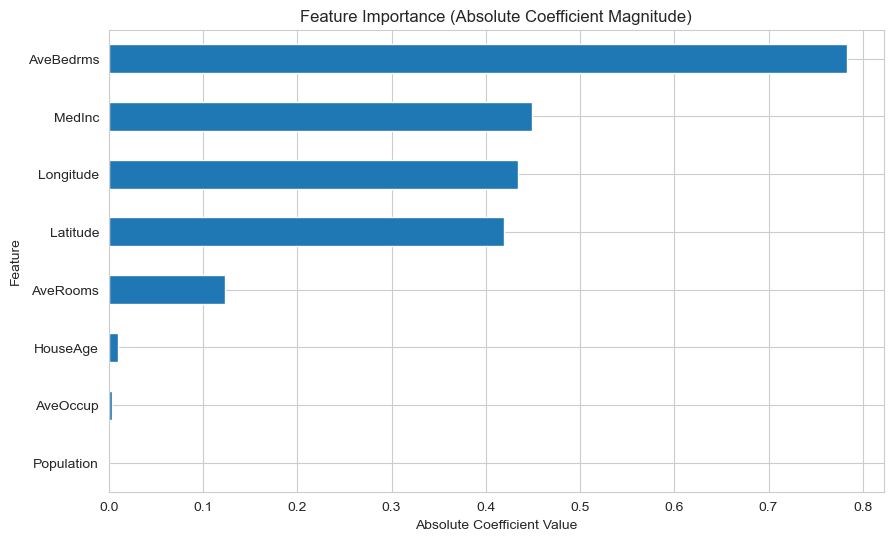

In [24]:
# Plot feature importance
plt.figure(figsize=(10, 6))
coeffs.abs().sort_values().plot(kind='barh')
plt.title('Feature Importance (Absolute Coefficient Magnitude)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.grid(True)
plt.show()

In [25]:
# Additional Analysis: Feature importance with standardized features
from sklearn.preprocessing import StandardScaler

# Scale features to make coefficients more comparable
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain model on scaled features
mlr_model_scaled = LinearRegression()
mlr_model_scaled.fit(X_train_scaled, y_train)

# Display importance with scaled features
coeffs_scaled = pd.Series(mlr_model_scaled.coef_, index=X.columns)
coeffs_scaled_sorted = coeffs_scaled.abs().sort_values(ascending=False)

print("\nFeature importance with standardized features:")
print(coeffs_scaled_sorted)


Feature importance with standardized features:
Latitude      0.896929
Longitude     0.869842
MedInc        0.854383
AveBedrms     0.339259
AveRooms      0.294410
HouseAge      0.122546
AveOccup      0.040829
Population    0.002308
dtype: float64


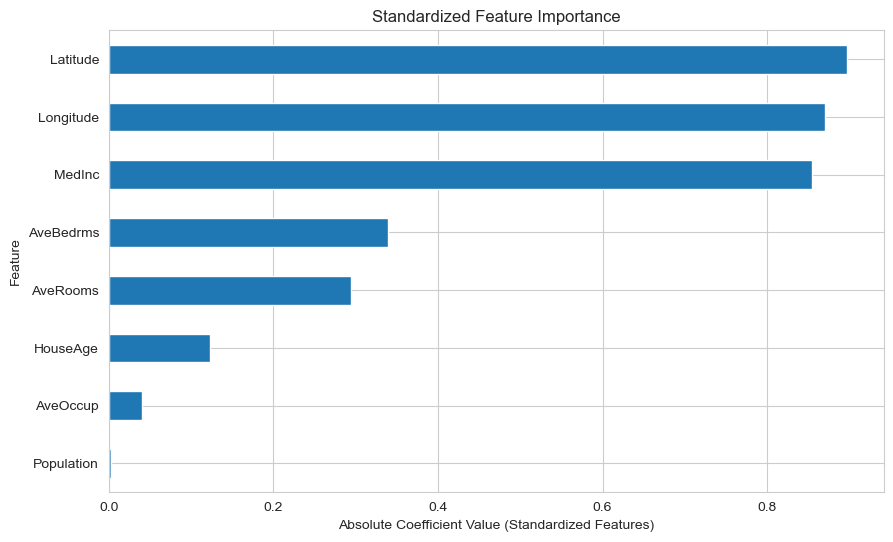


Note: Standardized coefficients provide a more fair comparison when features have different scales.
For example, MedInc is measured in tens of thousands of dollars while AveRooms is just a count.


In [26]:
plt.figure(figsize=(10, 6))
coeffs_scaled.abs().sort_values().plot(kind='barh')
plt.title('Standardized Feature Importance')
plt.xlabel('Absolute Coefficient Value (Standardized Features)')
plt.ylabel('Feature')
plt.grid(True)
plt.show()

print("\nNote: Standardized coefficients provide a more fair comparison when features have different scales.")
print("For example, MedInc is measured in tens of thousands of dollars while AveRooms is just a count.")

<a id="assumption-checking"></a>
## Assumption Checking

Let's check whether our Multiple Linear Regression model meets the key assumptions we discussed earlier:


--- Checking Linear Regression Assumptions ---


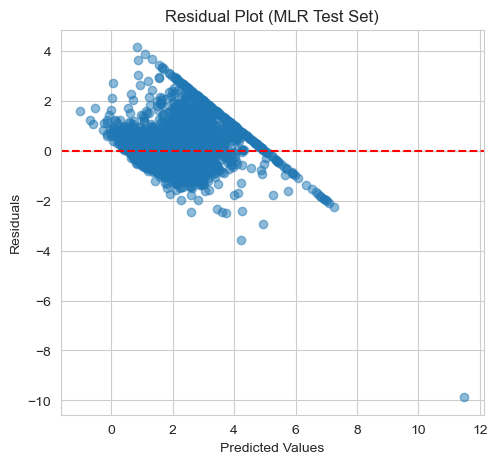

In [27]:
# --- Check Linear Regression Assumptions ---
print("\n--- Checking Linear Regression Assumptions ---")

# Calculate residuals for test set
residuals_test_mlr = y_test - y_pred_test_mlr

# 1. Linearity & Homoscedasticity Check
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_test_mlr, residuals_test_mlr, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (MLR Test Set)")
plt.grid(True)

In [ ]:
# Add a LOWESS smoothed line to help detect patterns
from scipy.stats import gaussian_kde

# Sort for line plot
sorted_idx = np.argsort(y_pred_test_mlr)
sorted_pred = y_pred_test_mlr[sorted_idx]
sorted_resid = residuals_test_mlr[sorted_idx]

# Add trend line with moving average
from scipy.ndimage import gaussian_filter1d
smooth_resid = gaussian_filter1d(sorted_resid, sigma=50)
plt.plot(sorted_pred, smooth_resid, 'r-', linewidth=2)

# Residuals vs. one important feature
plt.subplot(1, 2, 2)
plt.scatter(X_test['MedInc'], residuals_test_mlr, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Median Income")
plt.ylabel("Residuals")
plt.title("Residuals vs. Median Income")
plt.grid(True)

# Add trend line
sorted_idx = np.argsort(X_test['MedInc'])
sorted_x = X_test['MedInc'][sorted_idx]
sorted_resid = residuals_test_mlr[sorted_idx]
smooth_resid = gaussian_filter1d(sorted_resid, sigma=50)
plt.plot(sorted_x, smooth_resid, 'r-', linewidth=2)

plt.tight_layout()
plt.show()

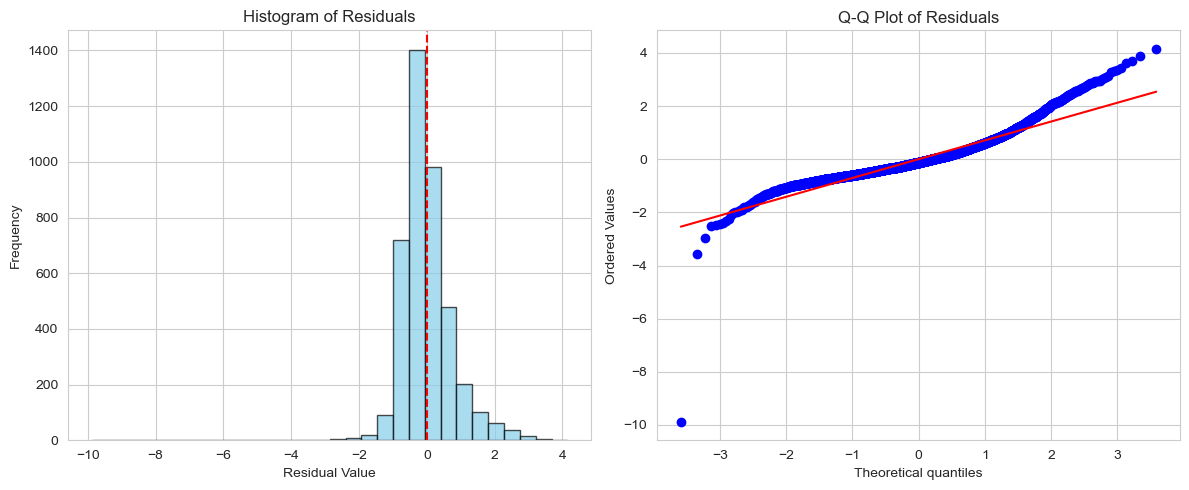

In [29]:
# 2. Normality of Residuals Check
plt.figure(figsize=(12, 5))

# Histogram of residuals
plt.subplot(1, 2, 1)
plt.hist(residuals_test_mlr, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

# Q-Q plot
import scipy.stats as stats
plt.subplot(1, 2, 2)
stats.probplot(residuals_test_mlr, plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [30]:
# 3. Additional Diagnostics
# Check for autocorrelation with Durbin-Watson test
from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(residuals_test_mlr)
print(f"Durbin-Watson statistic: {dw_stat:.4f}")
print("Note: Values close to 2 suggest no autocorrelation,")
print("      Values toward 0 suggest positive autocorrelation,")
print("      Values toward 4 suggest negative autocorrelation.")

Durbin-Watson statistic: 2.0407
Note: Values close to 2 suggest no autocorrelation,
      Values toward 0 suggest positive autocorrelation,
      Values toward 4 suggest negative autocorrelation.


In [31]:
# 4. Summary of Assumption Checks
print("\nSummary of Assumption Checks:")
print("1. Linearity & Homoscedasticity:")
if abs(np.corrcoef(y_pred_test_mlr, residuals_test_mlr)[0, 1]) < 0.1:
    print("   ✓ Residuals show no strong correlation with predicted values")
else:
    print("   ✗ There may be patterns in the residuals - potential non-linearity")


Summary of Assumption Checks:
1. Linearity & Homoscedasticity:
   ✓ Residuals show no strong correlation with predicted values


In [36]:
# Check variance consistency
residual_quartiles = pd.qcut(y_pred_test_mlr, 4)
variance_by_quartile = residuals_test_mlr.groupby(residual_quartiles, observed=False).var()
max_var = variance_by_quartile.max()
min_var = variance_by_quartile.min()
variance_ratio = max_var / min_var

if variance_ratio < 3:
    print("   ✓ Residual variance is relatively consistent across predicted values")
else:
    print("   ✗ Residual variance varies considerably - potential heteroscedasticity")

   ✓ Residual variance is relatively consistent across predicted values


In [37]:
# Check normality of residuals
_, norm_p_value = stats.shapiro(residuals_test_mlr)
if norm_p_value > 0.05:
    print("2. Normality: ✓ Residuals appear normally distributed (Shapiro-Wilk test)")
else:
    print("2. Normality: ✗ Residuals may not be normally distributed")
    print(f"   (Shapiro-Wilk p-value: {norm_p_value:.6f})")

2. Normality: ✗ Residuals may not be normally distributed
   (Shapiro-Wilk p-value: 0.000000)


In [38]:
# Check independence (using Durbin-Watson as proxy)
if 1.5 < dw_stat < 2.5:
    print("3. Independence: ✓ No significant autocorrelation detected (Durbin-Watson test)")
else:
    print("3. Independence: ✗ Possible autocorrelation in residuals")

3. Independence: ✓ No significant autocorrelation detected (Durbin-Watson test)



Multicollinearity Check:


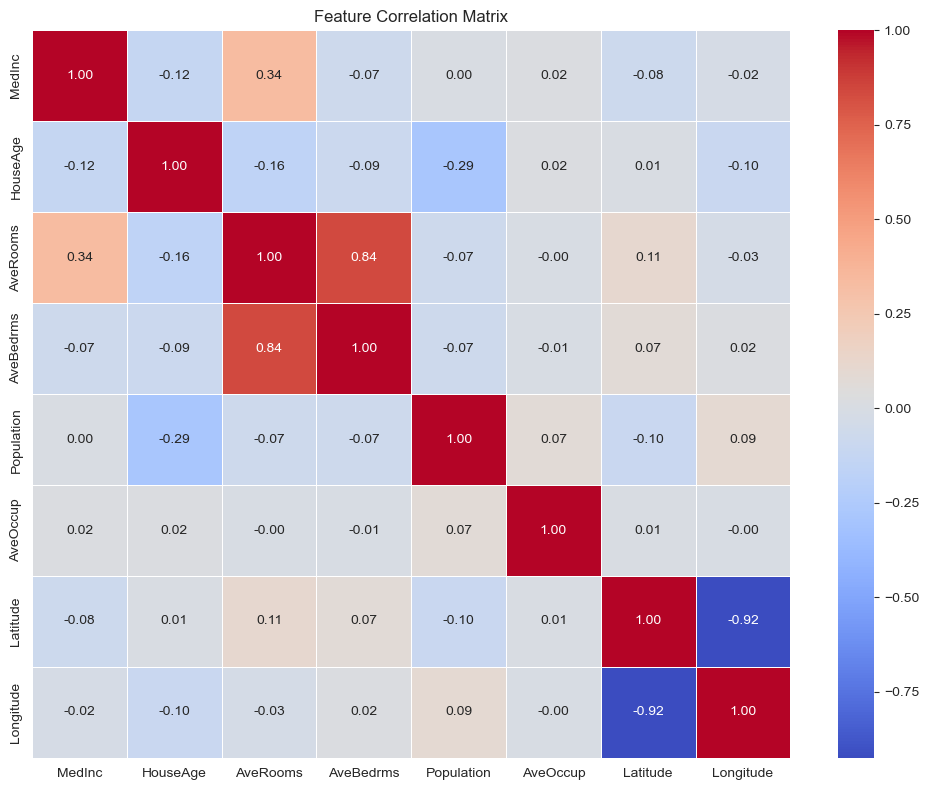

In [39]:
# 5. Check for Multicollinearity
print("\nMulticollinearity Check:")
correlation_matrix = X_train.corr()

# Plot correlation matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [40]:
# Highlight potentially problematic correlations
high_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_correlations.append((correlation_matrix.columns[i], 
                                      correlation_matrix.columns[j], 
                                      correlation_matrix.iloc[i, j]))

if high_correlations:
    print("Potential multicollinearity issues (correlations > 0.7):")
    for var1, var2, corr in high_correlations:
        print(f"  {var1} & {var2}: {corr:.4f}")
else:
    print("No strong correlations (>0.7) detected between features.")

Potential multicollinearity issues (correlations > 0.7):
  AveRooms & AveBedrms: 0.8362
  Latitude & Longitude: -0.9245


<a id="interactive-exercises"></a>
## Interactive Exercises

Now let's add some exercises that you can modify and explore to deepen your understanding:

### Exercise 1: Polynomial Features

Linear regression assumes a linear relationship between features and the target. Let's try adding polynomial features to capture possible non-linear relationships:

In [61]:
# --- Exercise: Adding Polynomial Features ---
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Create a degree-2 polynomial feature transformer
poly = PolynomialFeatures(degree=2, include_bias=False)

# Apply to our one important feature (MedInc)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train model with polynomial features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Make predictions
y_pred_train_poly = poly_model.predict(X_train_poly)
y_pred_test_poly = poly_model.predict(X_test_poly)

# Evaluate
r2_train_poly = r2_score(y_train, y_pred_train_poly)
r2_test_poly = r2_score(y_test, y_pred_test_poly)
rmse_test_poly = np.sqrt(mean_squared_error(y_test, y_pred_test_poly))

print("\n--- Polynomial Regression Results ---")
print(f"Training R²: {r2_train_poly:.4f}")
print(f"Test R²: {r2_test_poly:.4f}")
print(f"Test RMSE: {rmse_test_poly:.4f}")


--- Polynomial Regression Results ---
Training R²: 0.6853
Test R²: 0.6457
Test RMSE: 0.6814


In [63]:
X_train_poly.shape

(16512, 44)

In [68]:
X_train.values.shape

(16512, 8)

In [ ]:
# Compare with SLR
print("\nComparison with Simple Linear Regression:")
print(f"  Polynomial R²:  {r2_test_poly:.4f}")
print(f"  Simple Linear R²: {r2_test_slr:.4f}")
print(f"  Improvement: {r2_test_poly - r2_test_slr:.4f}")

# Visualize the polynomial fit
plt.figure(figsize=(10, 6))
# Sort for smooth curve
sort_idx = np.argsort(X_test['MedInc'])
x_sorted = X_test['MedInc'][sort_idx]
pred_sorted = y_pred_test_poly[sort_idx]

plt.scatter(X_test['MedInc'], y_test, alpha=0.5, label='Actual')
plt.plot(x_sorted, pred_sorted, color='red', linewidth=2, label='Polynomial Prediction')
plt.xlabel('Median Income ($10k)')
plt.ylabel('Median House Value ($100k)')
plt.title('Polynomial Regression: MedInc vs. MedHouseVal (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

print("\nQuestion to consider: Does the polynomial model improve the fit?")
print("How do the residuals of the polynomial model compare to the linear model?")
print("Would you choose the polynomial model over the linear model? Why or why not?")

### Exercise 2: Feature Selection

Let's explore whether we can build a simpler model with just a few important features:

In [44]:
# --- Exercise: Feature Selection ---
# Using the top 3 features from the importance analysis
top_features = coeffs_scaled_sorted.index[:3].tolist()
print(f"\n--- Using Top 3 Features: {top_features} ---")

# Extract selected features
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

# Train model
selected_model = LinearRegression()
selected_model.fit(X_train_selected, y_train)

# Evaluate
y_pred_test_selected = selected_model.predict(X_test_selected)
r2_test_selected = r2_score(y_test, y_pred_test_selected)
rmse_test_selected = np.sqrt(mean_squared_error(y_test, y_pred_test_selected))

print(f"Test R² with selected features: {r2_test_selected:.4f}")
print(f"Test RMSE with selected features: {rmse_test_selected:.4f}")

# Compare with full model
print("\nComparison with full MLR model:")
print(f"  Selected Features R²: {r2_test_selected:.4f}")
print(f"  All Features R²:      {r2_test_mlr:.4f}")
print(f"  Difference:           {r2_test_mlr - r2_test_selected:.4f}")

print("\nQuestion to consider: Is the simpler model with fewer features")
print("good enough compared to the full model?")
print("What are the tradeoffs between model complexity and performance?")


--- Using Top 3 Features: ['Latitude', 'Longitude', 'MedInc'] ---
Test R² with selected features: 0.5721
Test RMSE with selected features: 0.7489

Comparison with full MLR model:
  Selected Features R²: 0.5721
  All Features R²:      0.5758
  Difference:           0.0037

Question to consider: Is the simpler model with fewer features
good enough compared to the full model?
What are the tradeoffs between model complexity and performance?


<a id="practice-questions"></a>
## Practice Questions

1. In the Multiple Linear Regression model, which feature had the strongest influence on house prices? How do you know this, and what does this tell you about the California housing market?

2. Compare the performance of the Simple Linear Regression model (using only MedInc) with the Multiple Linear Regression model (using all features). What percentage of the variance in house prices can be explained by median income alone?

3. Based on the residual plots we examined, do you think the linear regression assumptions are reasonably satisfied? Which assumption(s) might be violated, and how might this affect our model interpretations?

4. If we wanted to predict the median house value for a new district with median income of $70,000 (7.0 in the dataset units), the average house age of 30 years, and 5 average rooms per household, how would we do this using our trained model?

5. Our analysis showed potential multicollinearity between certain features. What specific problems can multicollinearity cause in linear regression models, and how might we address this issue?

6. The polynomial regression model in the exercise section added quadratic terms for median income. Compare this approach to the simple linear model - did it improve performance? What does this suggest about the relationship between income and house prices?

7. Looking at the standardized coefficients, did any features have negative relationships with house prices? Why might these features have an inverse relationship with housing values?

8. How would you modify our approach if you discovered that the residuals showed strong heteroscedasticity (non-constant variance)?

9. If we were building a predictive model for real estate valuation, would you recommend using the full model with all eight features or a simpler model with fewer features? Justify your answer based on the analysis.

10. We evaluated our models using several metrics (MSE, RMSE, MAE, R²). Which metric(s) would you prioritize when explaining model performance to:
    a) A real estate developer trying to predict housing prices in specific areas
    b) A data scientist colleague working on improving the model
    c) A government agency studying housing affordability


--- Part 2: Underfitting/Overfitting Demo ---


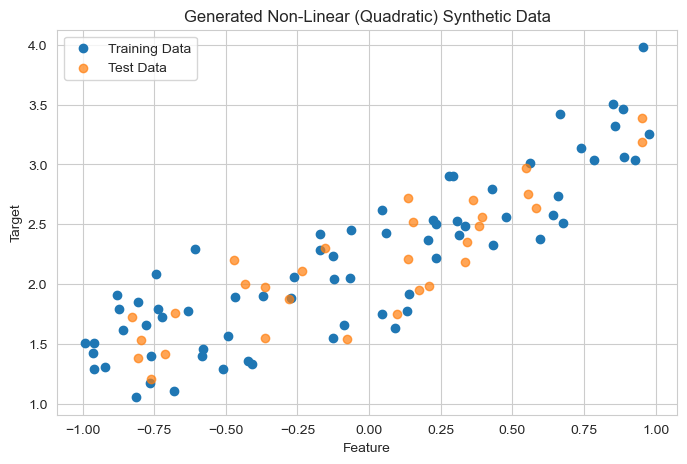

In [69]:
# --- Imports for Polynomial Features and Pipelines ---
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

print("\n--- Part 2: Underfitting/Overfitting Demo ---")

# --- Generate Non-linear Synthetic Data (Quadratic) ---
np.random.seed(0) # for reproducibility
n_samples = 100
X_synth = 2 * np.random.rand(n_samples, 1) - 1 # Features from -1 to 1
# Quadratic relationship: y = 0.5 * x^2 + 1 * x + 2 + noise
y_synth = 0.5 * X_synth**2 + 1 * X_synth + 2 + np.random.randn(n_samples, 1) * 0.3 # Add Gaussian noise

X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(
    X_synth, y_synth, test_size=0.3, random_state=42) # Use a slightly larger test set for clearer demo

plt.figure(figsize=(8, 5))
plt.scatter(X_train_synth, y_train_synth, label="Training Data")
plt.scatter(X_test_synth, y_test_synth, label="Test Data", alpha=0.7)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Generated Non-Linear (Quadratic) Synthetic Data")
plt.legend()
plt.grid(True)
plt.show() # Uncomment to display plot


--- A: Demonstrating Underfitting ---
Linear Fit - Train RMSE: 0.3326, Test RMSE: 0.2756


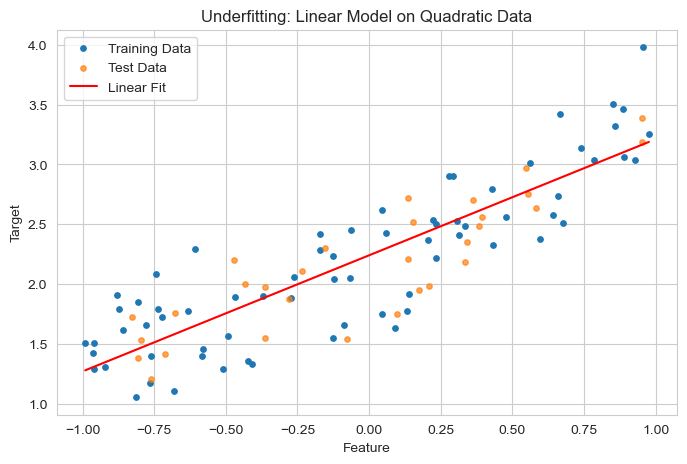

In [70]:
# --- A: Demonstrate Underfitting with Linear Regression ---
print("\n--- A: Demonstrating Underfitting ---")
lin_reg = LinearRegression()
lin_reg.fit(X_train_synth, y_train_synth)

# Evaluate
y_pred_train_lin = lin_reg.predict(X_train_synth)
y_pred_test_lin = lin_reg.predict(X_test_synth)
rmse_train_lin = np.sqrt(mean_squared_error(y_train_synth, y_pred_train_lin))
rmse_test_lin = np.sqrt(mean_squared_error(y_test_synth, y_pred_test_lin))
print(f"Linear Fit - Train RMSE: {rmse_train_lin:.4f}, Test RMSE: {rmse_test_lin:.4f}")

# Visualize
plt.figure(figsize=(8, 5))
plt.scatter(X_train_synth, y_train_synth, label="Training Data", s=15)
plt.scatter(X_test_synth, y_test_synth, label="Test Data", alpha=0.7, s=15)
plt.plot(np.sort(X_synth, axis=0), lin_reg.predict(np.sort(X_synth, axis=0)), color='red', label="Linear Fit")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Underfitting: Linear Model on Quadratic Data")
plt.legend()
plt.grid(True)
plt.show() # Uncomment to display plot
# Observation: The straight line clearly fails to capture the curve. Both train and test errors are high.


--- B: Polynomial Regression & Overfitting ---
Degree 1: Train RMSE = 0.3326, Test RMSE = 0.2756
Degree 2: Train RMSE = 0.3103, Test RMSE = 0.2605
Degree 15: Train RMSE = 0.2879, Test RMSE = 0.3051


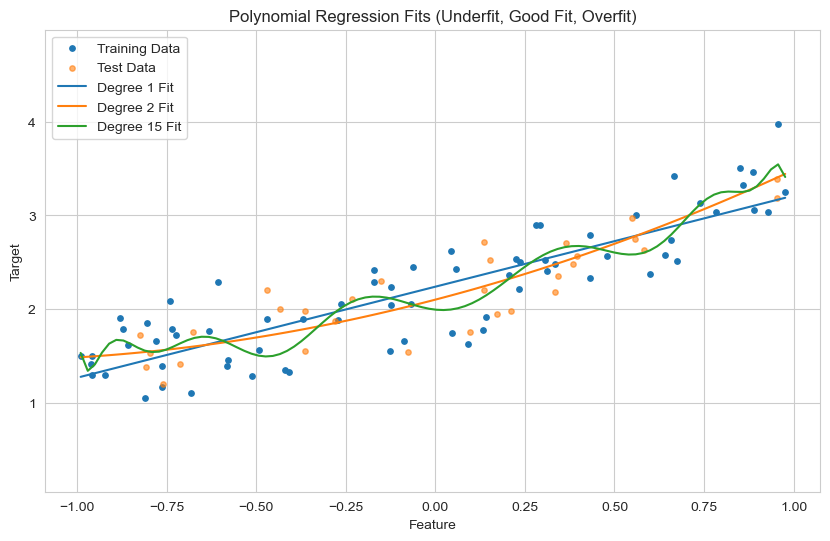

In [71]:
# --- B: Introduce Polynomial Regression & Demonstrate Overfitting ---
print("\n--- B: Polynomial Regression & Overfitting ---")
# We'll use Scikit-learn's Pipeline to combine PolynomialFeatures and LinearRegression.

train_errors, test_errors = [], []
degrees = [1, 2, 15] # Degrees to test: Underfit, Good Fit, Overfit

plt.figure(figsize=(10, 6))
plt.scatter(X_train_synth, y_train_synth, label="Training Data", s=15)
plt.scatter(X_test_synth, y_test_synth, label="Test Data", alpha=0.6, s=15)

for degree in degrees:
    # Create pipeline: 1. Add polynomial features, 2. Fit linear regression
    polynomial_regression = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lin_reg", LinearRegression()),
    ])

    polynomial_regression.fit(X_train_synth, y_train_synth)

    # Predictions
    y_pred_train_poly = polynomial_regression.predict(X_train_synth)
    y_pred_test_poly = polynomial_regression.predict(X_test_synth)

    # Calculate errors
    rmse_train = np.sqrt(mean_squared_error(y_train_synth, y_pred_train_poly))
    rmse_test = np.sqrt(mean_squared_error(y_test_synth, y_pred_test_poly))
    train_errors.append(rmse_train)
    test_errors.append(rmse_test)

    print(f"Degree {degree}: Train RMSE = {rmse_train:.4f}, Test RMSE = {rmse_test:.4f}")

    # Plot the fit - need to generate points across the range for a smooth curve
    X_plot = np.linspace(X_synth.min(), X_synth.max(), 100).reshape(-1, 1)
    y_plot = polynomial_regression.predict(X_plot)
    plt.plot(X_plot, y_plot, label=f"Degree {degree} Fit")

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Polynomial Regression Fits (Underfit, Good Fit, Overfit)")
plt.legend()
plt.ylim(y_synth.min() - 1, y_synth.max() + 1) # Adjust y-limits for better view
plt.grid(True)
plt.show() # Uncomment to display plot

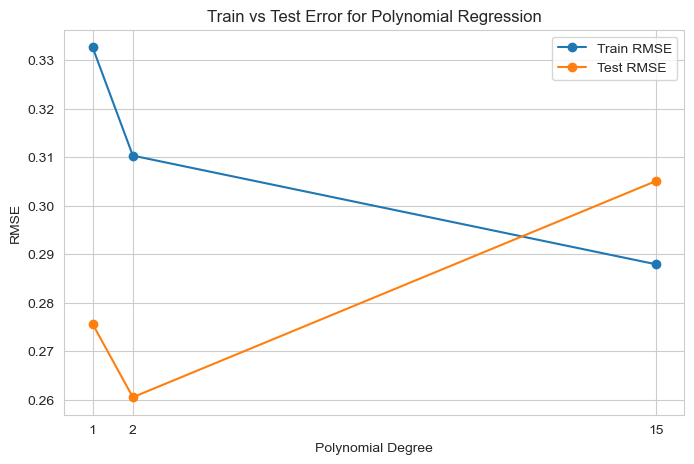

In [72]:
# Visualize Train vs Test Error
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_errors, "o-", label="Train RMSE")
plt.plot(degrees, test_errors, "o-", label="Test RMSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Train vs Test Error for Polynomial Regression")
plt.xticks(degrees)
plt.legend()
plt.grid(True)
plt.show() # Uncomment to display plot

In [ ]:
# Observations:
# Degree 1 (Linear): Underfits, high train/test error.
# Degree 2 (Quadratic): Fits well, low train/test error, both are close.
# Degree 15 (High Degree): Overfits! Train error is very low (model fits noise), but Test error explodes because the model doesn't generalize. The curve is excessively complex.